In [4]:
import numpy as np
from pathlib import Path
import os, sys, json
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pandas as pd
from scipy.stats import jarque_bera, shapiro, norm
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.multitest import multipletests

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead

# Important variables
SNRs = np.array([-np.inf, -13, -11, -9, -7, -5, -3])
SubIDs = ['01', '02', '03', '05', '06', '07', '08', '09', '11', '12', '13', '14', '15', '17', '19', '20', '22', '23', '24', '25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

# Argument 1: OU fit quality with LEAD formalism

This section migrates the old UPP workflow to LEAD and evaluates OU assumptions using:
- One-step standardized innovations
- Formal whiteness tests (Ljung-Box)
- Formal Gaussianity tests (Jarque-Bera and Shapiro)
- Predictive checks from model simulations

Note: this section intentionally does not compare OU against alternative models.

In [5]:
from scipy.stats import skew, kurtosis, probplot

def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path

def kalman_innovations_1d(
    states: np.ndarray,
    inputs: np.ndarray,
    tau: float,
    process_noise: float,
    measure_noise: float,
    input_weight: float = 0.0,
    dt: float = 1.0
):
    """Return filtered states, innovations, standardized innovations, and innovation variance."""
    A = 1.0 - dt / tau
    B = input_weight * dt
    Q = (process_noise ** 2) * dt
    R = measure_noise ** 2

    n_trials, n_steps = states.shape
    filtered = np.zeros_like(states, dtype=float)
    innovations = np.zeros_like(states, dtype=float)
    std_innov = np.zeros_like(states, dtype=float)
    innov_var = np.full_like(states, np.nan, dtype=float)

    for tr in range(n_trials):
        x = float(states[tr, 0])
        P = 1.0
        filtered[tr, 0] = x
        innovations[tr, 0] = 0.0
        std_innov[tr, 0] = 0.0

        for t in range(1, n_steps):
            x_pred = A * x + B * float(inputs[tr, t - 1])
            P_pred = A * A * P + Q

            e_t = float(states[tr, t]) - x_pred
            S_t = P_pred + R
            K_t = P_pred / S_t

            x = x_pred + K_t * e_t
            P = (1.0 - K_t) * P_pred

            filtered[tr, t] = x
            innovations[tr, t] = e_t
            innov_var[tr, t] = S_t
            std_innov[tr, t] = e_t / np.sqrt(S_t) if S_t > 0 else np.nan

    return filtered, innovations, std_innov, innov_var

def compute_trial_summary_stats(x: np.ndarray) -> dict:
    """Compute summary statistics trial-wise then return median across trials."""
    means = np.mean(x, axis=1)
    vars_ = np.var(x, axis=1)
    acf1 = np.array([acf(tr, nlags=1, fft=True)[1] for tr in x])
    skews = skew(x, axis=1, bias=False, nan_policy='omit')
    kurts = kurtosis(x, axis=1, fisher=True, bias=False, nan_policy='omit')
    return {
        'mean_median': float(np.nanmedian(means)),
        'var_median': float(np.nanmedian(vars_)),
        'acf1_median': float(np.nanmedian(acf1)),
        'skew_median': float(np.nanmedian(skews)),
        'kurtosis_median': float(np.nanmedian(kurts)),
    }

def median_abs_gap(obs_stats: dict, sim_stats: dict, eps: float = 1e-8) -> dict:
    out = {}
    for k in obs_stats.keys():
        scale = max(abs(obs_stats[k]), eps)
        out[f'{k}_rel_gap'] = float(abs(obs_stats[k] - sim_stats[k]) / scale)
    out['predictive_global_gap'] = float(np.mean(list(out.values())))
    return out

In [8]:
# Save diagnostics + resilient save helper.
import time
import tempfile
import platform
import subprocess
from datetime import datetime


def _safe_run(cmd):
    try:
        p = subprocess.run(cmd, capture_output=True, text=True, check=False)
        out = (p.stdout or "").strip()
        err = (p.stderr or "").strip()
        return p.returncode, out, err
    except Exception as exc:
        return 1, "", f"{type(exc).__name__}: {exc}"


def snapshot_fs_context(target_dir: Path, label: str = "runtime") -> dict:
    """Collect a compact environment snapshot to diagnose intermittent write failures."""
    target_dir = Path(target_dir).resolve()
    rows = {
        "ts": datetime.now().isoformat(timespec="seconds"),
        "label": label,
        "cwd": str(Path.cwd()),
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "uid": os.getuid() if hasattr(os, "getuid") else None,
        "gid": os.getgid() if hasattr(os, "getgid") else None,
        "groups": ",".join(map(str, os.getgroups())) if hasattr(os, "getgroups") else "",
        "target_dir": str(target_dir),
        "target_exists": target_dir.exists(),
        "target_w_ok": os.access(target_dir, os.W_OK),
    }

    # Parent permission chain.
    chain = [target_dir, target_dir.parent, target_dir.parent.parent, target_dir.parent.parent.parent]
    for i, p in enumerate(chain):
        key = f"p{i}"
        try:
            st = p.stat()
            rows[f"{key}_path"] = str(p)
            rows[f"{key}_mode"] = oct(st.st_mode & 0o777)
            rows[f"{key}_uid"] = st.st_uid
            rows[f"{key}_gid"] = st.st_gid
            rows[f"{key}_w_ok"] = os.access(p, os.W_OK)
        except Exception as exc:
            rows[f"{key}_path"] = str(p)
            rows[f"{key}_error"] = f"{type(exc).__name__}: {exc}"

    rc, out, err = _safe_run(["sh", "-lc", f"df -ih {target_dir}"])
    rows["df_ih_rc"] = rc
    rows["df_ih"] = out if out else err

    rc, out, err = _safe_run(["sh", "-lc", "mount | grep -E ' nfs | cifs | smb ' || true"])
    rows["mount_rc"] = rc
    rows["mount_snippet"] = out if out else err

    # File descriptor pressure in this process.
    try:
        pid = os.getpid()
        rows["pid"] = pid
        rows["open_fd_count"] = len(os.listdir(f"/proc/{pid}/fd"))
    except Exception as exc:
        rows["open_fd_error"] = f"{type(exc).__name__}: {exc}"

    return rows


def tiny_write_probe(target_dir: Path, prefix: str = "probe") -> tuple[bool, str]:
    """Create/delete a tiny file in target_dir to test real write capability."""
    target_dir = Path(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)
    probe = target_dir / f".{prefix}_{int(time.time() * 1000)}.tmp"
    try:
        with open(probe, "wb") as f:
            f.write(b"ok")
            f.flush()
            os.fsync(f.fileno())
        probe.unlink(missing_ok=True)
        return True, "ok"
    except Exception as exc:
        return False, f"{type(exc).__name__}: {exc}"


def resilient_savefig(fig, final_path: Path, dpi: int = 150, retries: int = 3, pause_s: float = 0.35):
    """Write via temp file + replace, with retries and structured diagnostics."""
    final_path = Path(final_path)
    final_path.parent.mkdir(parents=True, exist_ok=True)

    err_last = None
    for attempt in range(1, retries + 1):
        ok_probe, probe_msg = tiny_write_probe(final_path.parent, prefix=f"pre_save_a{attempt}")
        tmp_name = f".{final_path.stem}.tmp.{os.getpid()}.{int(time.time()*1000)}.png"
        tmp_path = final_path.parent / tmp_name

        try:
            fig.savefig(tmp_path, dpi=dpi)
            os.replace(tmp_path, final_path)
            return {
                "ok": True,
                "attempt": attempt,
                "probe_ok": ok_probe,
                "probe_msg": probe_msg,
                "path": str(final_path),
            }
        except PermissionError as exc:
            err_last = exc
            try:
                tmp_path.unlink(missing_ok=True)
            except Exception:
                pass
            time.sleep(pause_s * attempt)
        except Exception as exc:
            err_last = exc
            try:
                tmp_path.unlink(missing_ok=True)
            except Exception:
                pass
            break

    return {
        "ok": False,
        "attempt": retries,
        "probe_ok": ok_probe,
        "probe_msg": probe_msg,
        "path": str(final_path),
        "error": f"{type(err_last).__name__}: {err_last}" if err_last else "UnknownError",
        "snapshot": snapshot_fs_context(final_path.parent, label="savefig_failure"),
    }


def micro_save_stress_test(target_dir: Path, n_iter: int = 120, dpi: int = 90) -> pd.DataFrame:
    """Stress only file writing to separate FS issues from modeling code."""
    target_dir = Path(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)
    rows = []

    for i in range(n_iter):
        fig = plt.figure(figsize=(3.2, 2.2))
        ax = fig.add_subplot(111)
        ax.plot([0, 1, 2], [i % 3, (i + 1) % 3, (i + 2) % 3])
        ax.set_title(f"stress {i}")

        out = target_dir / f"stress_{i:04d}.png"
        t0 = time.time()
        res = resilient_savefig(fig, out, dpi=dpi, retries=3, pause_s=0.20)
        elapsed_ms = (time.time() - t0) * 1000.0
        plt.close(fig)

        rows.append({
            "iter": i,
            "ok": bool(res.get("ok", False)),
            "attempt": res.get("attempt"),
            "elapsed_ms": elapsed_ms,
            "probe_ok": res.get("probe_ok"),
            "error": res.get("error", ""),
        })

        if not res.get("ok", False):
            snap = res.get("snapshot", {})
            rows[-1]["snapshot_mount"] = snap.get("mount_snippet", "")
            rows[-1]["snapshot_df"] = snap.get("df_ih", "")
            rows[-1]["snapshot_fd"] = snap.get("open_fd_count", "")
            break

    return pd.DataFrame(rows)

In [9]:
# One-time baseline snapshot + optional save stress test (run before main loop).
baseline_out_dir = Path("RestingStateResults") / "Active" / "early"
baseline_out_dir.mkdir(parents=True, exist_ok=True)

baseline_snapshot = snapshot_fs_context(baseline_out_dir, label="baseline")
baseline_df = pd.DataFrame([baseline_snapshot])
display(baseline_df.T)

probe_ok, probe_msg = tiny_write_probe(baseline_out_dir, prefix="manual_probe")
print("Write probe:", probe_ok, probe_msg)

# Toggle this to True when you want a focused filesystem-only reproducibility check.
RUN_SAVE_STRESS_TEST = False
if RUN_SAVE_STRESS_TEST:
    stress_dir = baseline_out_dir / "_stress_test"
    stress_df = micro_save_stress_test(stress_dir, n_iter=120, dpi=90)
    display(stress_df.tail(10))
    stress_df.to_csv(Path("RestingStateResults") / "Summaries" / "savefig_stress_log.csv", index=False)
    print("Stress-test failures:", int((~stress_df['ok']).sum()))

,0
ts,2026-04-21T11:05:42
label,baseline
cwd,/srv/elefanto/ConsciousnessTeam_Data/SOUNDMODE...
python,3.11.2
platform,Linux-6.1.0-32-amd64-x86_64-with-glibc2.36
uid,1006
gid,100
groups,100
target_dir,/srv/elefanto/ConsciousnessTeam_Data/SOUNDMODE...
target_exists,True


Write probe: True ok


In [11]:
# Main migration + diagnostics loop with resilient figure saving.
results_root = ensure_dir(Path("RestingStateResults"))
summary_root = ensure_dir(results_root / "Summaries")

if "resilient_savefig" not in globals():
    def resilient_savefig(fig, final_path: Path, dpi: int = 150, retries: int = 1, pause_s: float = 0.0):
        final_path = Path(final_path)
        final_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(final_path, dpi=dpi)
        return {"ok": True, "attempt": 1, "path": str(final_path)}

all_part_rows = []
all_ljung_rows = []
all_param_rows = []
save_fail_rows = []
run_context_rows = []

base_dir = repo_root.parent

for task in ['Active', 'Passive']:
    for period in ['late', 'early']:
        tmin, tmax = (300, 500) if period == 'late' else (100, 200)
        out_dir = ensure_dir(results_root / task / period)

        # Snapshot directory and mount state before each block.
        if "snapshot_fs_context" in globals():
            run_context_rows.append(snapshot_fs_context(out_dir, label=f"preloop_{task}_{period}"))

        for part in tqdm(range(20), desc=f"{task}-{period}"):
            print(part)
            sub_id = SubIDs[part]
            data_ref = f"myEpochs_{task}/Epoch_{sub_id}-epo.fif"
            epochs_file = base_dir / data_ref

            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=RuntimeWarning)
                state_dict = lead.STG(epochs_file, tmin=tmin, tmax=tmax)

            if 0 not in state_dict:
                raise KeyError(f"Category 0 missing in STG output for {task}-{period}-part{part}.")

            state_arr = np.asarray(state_dict[0], dtype=float)
            input_arr = np.zeros_like(state_arr)

            linear = lead.model.StratifiedLinear(
                tau=10, process_noise=0.1, measure_noise=0.1,
                w0=0, w1=0, w2=0, w3=0, w4=0, w5=0, w6=0
            )
            linear.fit(
                state_series={0: state_arr},
                input_series={0: input_arr},
                init_params=[10, 0.1, 0.1] + [0] * 7,
                bounds=[(1, 25), (0.01, 1), (0.01, 1)] + [(0, 1)] * 7,
                fixed_params=[f'w{i}' for i in range(7)],
                feedback=False,
            )

            params = linear.get_params()
            all_param_rows.append({
                'task': task,
                'period': period,
                'part': part,
                'sub_id': sub_id,
                **params,
            })

            filtered, innovations, std_innov, innov_var = kalman_innovations_1d(
                states=state_arr,
                inputs=input_arr,
                tau=float(params['tau']),
                process_noise=float(params['process_noise']),
                measure_noise=float(params['measure_noise']),
                input_weight=float(params.get('w0', 0.0)),
                dt=float(linear.dt),
            )

            std_flat = std_innov[:, 1:].ravel()
            std_flat = std_flat[np.isfinite(std_flat)]

            if std_flat.size < 8:
                raise ValueError(f"Too few innovation samples for tests in {task}-{period}-part{part}.")

            jb_stat, jb_p = jarque_bera(std_flat)
            if std_flat.size > 5000:
                shapiro_sample = np.random.default_rng(0).choice(std_flat, size=5000, replace=False)
            else:
                shapiro_sample = std_flat
            sh_stat, sh_p = shapiro(shapiro_sample)

            ljung_lags = [5, 10, 20]
            trial_acf = np.array([acf(tr[1:], nlags=10, fft=True) for tr in std_innov])
            avg_acf = np.nanmean(trial_acf, axis=0)
            ci = 1.96 / np.sqrt(state_arr.shape[1])

            for lag in ljung_lags:
                pvals_lag = []
                for tr in range(std_innov.shape[0]):
                    lb = acorr_ljungbox(std_innov[tr, 1:], lags=[lag], return_df=True)
                    pvals_lag.append(float(lb['lb_pvalue'].iloc[0]))
                lag_row = {
                    'task': task,
                    'period': period,
                    'part': part,
                    'sub_id': sub_id,
                    'lag': lag,
                    'lb_p_median': float(np.median(pvals_lag)),
                    'lb_p_min': float(np.min(pvals_lag)),
                    'lb_p_frac_lt_0_05': float(np.mean(np.array(pvals_lag) < 0.05)),
                }
                all_ljung_rows.append(lag_row)

            sim = linear.measure_simulations({0: input_arr})[0]
            obs_stats = compute_trial_summary_stats(state_arr)
            sim_stats = compute_trial_summary_stats(sim)
            gap_stats = median_abs_gap(obs_stats, sim_stats)

            all_part_rows.append({
                'task': task,
                'period': period,
                'part': part,
                'sub_id': sub_id,
                'n_trials': int(state_arr.shape[0]),
                'n_steps': int(state_arr.shape[1]),
                'tau': float(params['tau']),
                'process_noise': float(params['process_noise']),
                'measure_noise': float(params['measure_noise']),
                'jarque_bera_stat': float(jb_stat),
                'jarque_bera_p': float(jb_p),
                'shapiro_stat': float(sh_stat),
                'shapiro_p': float(sh_p),
                'std_innov_mean': float(np.nanmean(std_flat)),
                'std_innov_std': float(np.nanstd(std_flat)),
                'acf1_avg': float(avg_acf[1]),
                **obs_stats,
                **{f'sim_{k}': v for k, v in sim_stats.items()},
                **gap_stats,
            })

            fig = plt.figure(figsize=(15, 11))
            gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1])
            plt.suptitle(f"OU Diagnostics (LEAD): {task} {period} - Part {part}", fontsize=15, fontweight='bold')

            ax1 = fig.add_subplot(gs[0, :])
            ax1.plot(state_arr[0], color='black', alpha=0.35, label='Observed (trial 1)')
            ax1.plot(filtered[0], color='tab:blue', lw=1.5, label='Filtered mean')
            ax1.set_title('Tracking on one trial')
            ax1.legend(loc='upper right')

            ax2 = fig.add_subplot(gs[1, 0])
            sns.histplot(std_flat, stat='density', bins=50, ax=ax2, color='tab:green', alpha=0.4)
            x = np.linspace(np.min(std_flat), np.max(std_flat), 200)
            ax2.plot(x, norm.pdf(x, 0, 1), color='k', lw=2, label='N(0,1)')
            ax2.set_title(f"Standardized innovations\nJB p={jb_p:.3g}, Shapiro p={sh_p:.3g}")
            ax2.legend(fontsize='small')

            ax3 = fig.add_subplot(gs[1, 1])
            _ = probplot(std_flat, dist='norm', plot=ax3)
            ax3.set_title('QQ plot vs Normal')

            ax4 = fig.add_subplot(gs[2, 0])
            ax4.stem(range(11), avg_acf)
            ax4.axhline(ci, color='tab:red', ls='--', alpha=0.6)
            ax4.axhline(-ci, color='tab:red', ls='--', alpha=0.6)
            ax4.axhline(0, color='tab:red', lw=1)
            ax4.set_ylim([-0.3, 1.05])
            ax4.set_title('Average innovation ACF (10 lags)')

            ax5 = fig.add_subplot(gs[2, 1])
            bars = [
                all_ljung_rows[-3]['lb_p_frac_lt_0_05'],
                all_ljung_rows[-2]['lb_p_frac_lt_0_05'],
                all_ljung_rows[-1]['lb_p_frac_lt_0_05'],
            ]
            ax5.bar(['lag5', 'lag10', 'lag20'], bars, color=['#4C78A8', '#F58518', '#54A24B'])
            ax5.axhline(0.05, color='tab:red', ls='--', alpha=0.6, label='0.05 reference')
            ax5.set_ylim([0, 1])
            ax5.set_title('Fraction of trials with Ljung-Box p < 0.05')
            ax5.legend(fontsize='small')

            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            save_target = out_dir / f"part{part}_ou_diagnostics.png"
            save_res = resilient_savefig(fig, save_target, dpi=150, retries=3, pause_s=0.35)

            if not save_res.get("ok", False):
                save_fail_rows.append({
                    "task": task,
                    "period": period,
                    "part": part,
                    "sub_id": sub_id,
                    "path": str(save_target),
                    "attempt": save_res.get("attempt"),
                    "probe_ok": save_res.get("probe_ok"),
                    "probe_msg": save_res.get("probe_msg"),
                    "error": save_res.get("error", ""),
                    "snapshot_json": json.dumps(save_res.get("snapshot", {}), ensure_ascii=True),
                })
                print(f"savefig failed: {task}-{period}-part{part} -> {save_res.get('error', 'unknown')}")

            plt.close(fig)

diag_df = pd.DataFrame(all_part_rows)
ljung_df = pd.DataFrame(all_ljung_rows)
params_df = pd.DataFrame(all_param_rows)
save_fail_df = pd.DataFrame(save_fail_rows)
context_df = pd.DataFrame(run_context_rows)

diag_df.to_csv(summary_root / "diagnostics_raw.csv", index=False)
ljung_df.to_csv(summary_root / "ljungbox_raw.csv", index=False)
params_df.to_csv(summary_root / "fitted_params.csv", index=False)
save_fail_df.to_csv(summary_root / "savefig_failures.csv", index=False)
context_df.to_csv(summary_root / "savefig_context_snapshots.csv", index=False)

if not save_fail_df.empty:
    print(f"Detected savefig failures: {len(save_fail_df)}")
    display(save_fail_df.tail(10))

Active-late:   0%|          | 0/20 [00:00<?, ?it/s]

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


Active-early:   0%|          | 0/20 [00:00<?, ?it/s]

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


Passive-late:   0%|          | 0/20 [00:00<?, ?it/s]

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


Passive-early:   0%|          | 0/20 [00:00<?, ?it/s]

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
savefig failed: Passive-early-part16 -> PermissionError: [Errno 13] Permission denied: '/srv/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder/RestingStateResults/Passive/early/.part16_ou_diagnostics.tmp.899719.1776774468369.png'
17
18
19
Detected savefig failures: 1


,task,period,part,sub_id,path,attempt,probe_ok,probe_msg,error,snapshot_json
0,Passive,early,16,22,RestingStateResults/Passive/early/part16_ou_di...,3,False,PermissionError: [Errno 13] Permission denied:...,PermissionError: [Errno 13] Permission denied:...,"{""ts"": ""2026-04-21T14:27:49"", ""label"": ""savefi..."


In [12]:
# Multiple-comparison correction and compact summaries.
diag_df = pd.read_csv(summary_root / "diagnostics_raw.csv")
ljung_df = pd.read_csv(summary_root / "ljungbox_raw.csv")

diag_corr = diag_df.copy()
diag_corr['jb_p_fdr'] = np.nan
diag_corr['shapiro_p_fdr'] = np.nan
diag_corr['jb_reject_fdr'] = False
diag_corr['shapiro_reject_fdr'] = False

for (task, period), g in diag_corr.groupby(['task', 'period']):
    idx = g.index.to_numpy()
    jb_reject, jb_pfdr, _, _ = multipletests(g['jarque_bera_p'].values, alpha=0.05, method='fdr_bh')
    sh_reject, sh_pfdr, _, _ = multipletests(g['shapiro_p'].values, alpha=0.05, method='fdr_bh')
    diag_corr.loc[idx, 'jb_p_fdr'] = jb_pfdr
    diag_corr.loc[idx, 'shapiro_p_fdr'] = sh_pfdr
    diag_corr.loc[idx, 'jb_reject_fdr'] = jb_reject
    diag_corr.loc[idx, 'shapiro_reject_fdr'] = sh_reject

ljung_corr = ljung_df.copy()
ljung_corr['lb_p_median_fdr'] = np.nan
ljung_corr['lb_reject_fdr'] = False

for (task, period, lag), g in ljung_corr.groupby(['task', 'period', 'lag']):
    idx = g.index.to_numpy()
    rej, pfdr, _, _ = multipletests(g['lb_p_median'].values, alpha=0.05, method='fdr_bh')
    ljung_corr.loc[idx, 'lb_p_median_fdr'] = pfdr
    ljung_corr.loc[idx, 'lb_reject_fdr'] = rej

compact_diag = (
    diag_corr.groupby(['task', 'period'], as_index=False)
    .agg(
        n_parts=('part', 'count'),
        frac_jb_reject_fdr=('jb_reject_fdr', 'mean'),
        frac_shapiro_reject_fdr=('shapiro_reject_fdr', 'mean'),
        median_jb_p_fdr=('jb_p_fdr', 'median'),
        median_shapiro_p_fdr=('shapiro_p_fdr', 'median'),
        median_predictive_gap=('predictive_global_gap', 'median'),
        median_abs_std_mean=('std_innov_mean', lambda x: np.median(np.abs(x))),
        median_std_std=('std_innov_std', 'median'),
    )
)

compact_ljung = (
    ljung_corr.groupby(['task', 'period', 'lag'], as_index=False)
    .agg(
        n_parts=('part', 'count'),
        frac_reject_fdr=('lb_reject_fdr', 'mean'),
        median_p_fdr=('lb_p_median_fdr', 'median'),
        median_frac_trials_lt_0_05=('lb_p_frac_lt_0_05', 'median'),
    )
)

diag_corr.to_csv(summary_root / "diagnostics_corrected.csv", index=False)
ljung_corr.to_csv(summary_root / "ljungbox_corrected.csv", index=False)
compact_diag.to_csv(summary_root / "diagnostics_compact_summary.csv", index=False)
compact_ljung.to_csv(summary_root / "ljungbox_compact_summary.csv", index=False)

display(compact_diag)
display(compact_ljung)

,task,period,n_parts,frac_jb_reject_fdr,frac_shapiro_reject_fdr,median_jb_p_fdr,median_shapiro_p_fdr,median_predictive_gap,median_abs_std_mean,median_std_std
0,Active,early,20,1.00,0.80,2.078187e-66,5.000304e-05,1.242308,3.050504e-18,0.999480
1,Active,late,20,0.95,0.70,1.241180e-39,6.972443e-04,1.327377,2.632522e-18,0.999543
2,Passive,early,20,1.00,0.95,8.790148e-148,1.463619e-09,1.066164,1.723140e-18,0.999409
3,Passive,late,20,1.00,0.80,1.511453e-198,6.318113e-09,1.159824,1.898682e-18,0.999466


,task,period,lag,n_parts,frac_reject_fdr,median_p_fdr,median_frac_trials_lt_0_05
0,Active,early,5,20,0.70,0.041062,0.588558
1,Active,early,10,20,0.85,0.009434,0.677244
2,Active,early,20,20,0.95,0.004620,0.695778
3,Active,late,5,20,0.80,0.035659,0.588033
4,Active,late,10,20,0.95,0.005416,0.691901
5,Active,late,20,20,0.95,0.001343,0.754263
6,Passive,early,5,20,0.75,0.038382,0.582171
7,Passive,early,10,20,0.80,0.017633,0.648825
8,Passive,early,20,20,0.85,0.012205,0.659739
9,Passive,late,5,20,0.70,0.028286,0.648038


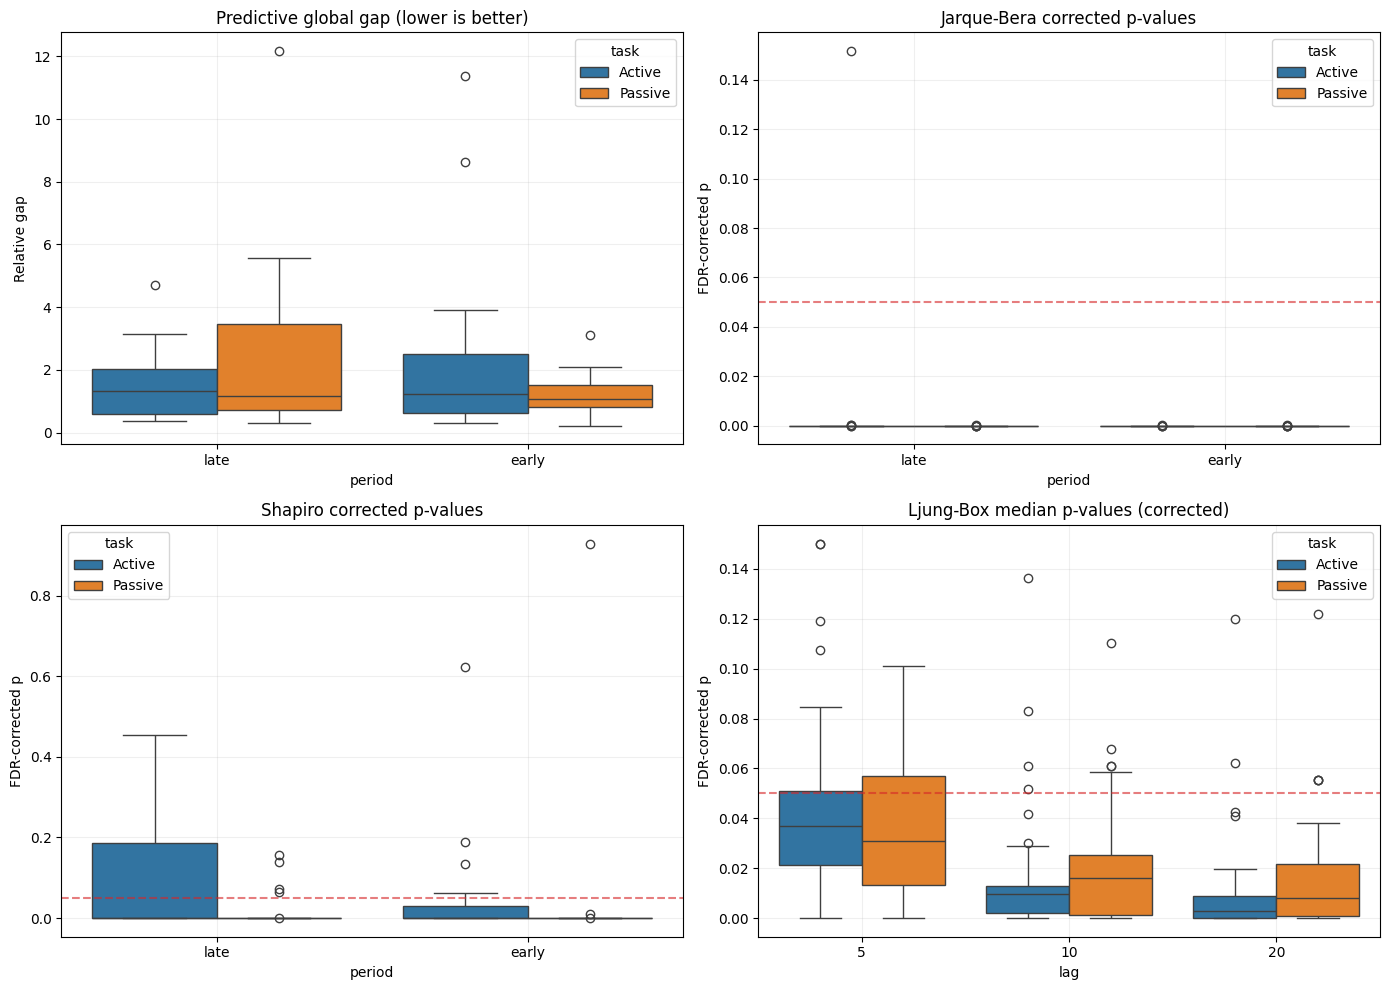

In [13]:
# Group-level figures from corrected outputs.
diag_corr = pd.read_csv(summary_root / "diagnostics_corrected.csv")
ljung_corr = pd.read_csv(summary_root / "ljungbox_corrected.csv")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=diag_corr, x='period', y='predictive_global_gap', hue='task', ax=axes[0, 0])
axes[0, 0].set_title('Predictive global gap (lower is better)')
axes[0, 0].set_ylabel('Relative gap')

sns.boxplot(data=diag_corr, x='period', y='jb_p_fdr', hue='task', ax=axes[0, 1])
axes[0, 1].axhline(0.05, ls='--', color='tab:red', alpha=0.6)
axes[0, 1].set_title('Jarque-Bera corrected p-values')
axes[0, 1].set_ylabel('FDR-corrected p')

sns.boxplot(data=diag_corr, x='period', y='shapiro_p_fdr', hue='task', ax=axes[1, 0])
axes[1, 0].axhline(0.05, ls='--', color='tab:red', alpha=0.6)
axes[1, 0].set_title('Shapiro corrected p-values')
axes[1, 0].set_ylabel('FDR-corrected p')

sns.boxplot(data=ljung_corr, x='lag', y='lb_p_median_fdr', hue='task', ax=axes[1, 1])
axes[1, 1].axhline(0.05, ls='--', color='tab:red', alpha=0.6)
axes[1, 1].set_title('Ljung-Box median p-values (corrected)')
axes[1, 1].set_ylabel('FDR-corrected p')

for ax in axes.ravel():
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(summary_root / "group_level_diagnostics.png", dpi=160)
plt.show()

# Interpretation checklist

Use the exported summary tables in `RestingStateResults/Summaries/` to evaluate OU adequacy:
- Innovation mean close to 0 and innovation SD close to 1
- Low fraction of FDR-significant Ljung-Box failures
- Low fraction of FDR-significant Gaussianity failures
- Small predictive global gap between observed and simulated summary statistics

A conservative criterion is to require these conditions jointly within each task-period combination.